In [1]:
# Imports
from pathlib import Path
from experiment.utils import TrainedModel, TrainedModelID, get_losses

import pandas as pd
import torch
from neuralhydrology.nh_run import start_run, eval_run, finetune
from experiment.eval import evaluate_models
import os
import yaml
import matplotlib.pyplot as plt

,Metric,sota_20
0,NSE (mean),-5.03
1,KGE (mean),0.59
2,Alpha-NSE (mean),0.95
3,Beta-NSE (mean),0.07
4,MSE (mean),2.07
5,RMSE (mean),1.2
6,Pearson-r (mean),0.87
7,Beta-KGE (mean),0.96
8,FHV (mean),-12.05
9,FMS (mean),180335.66


In [2]:
model = TrainedModel(TrainedModelID.SOTA_20)

df = pd.read_csv(model.metrics_file, dtype={'basin':str})
cutoff = 0.0
basin_data = df.loc[df['NSE'] > cutoff].sample(n=1)
basin = basin_data.basin.iloc[0]
nse = basin_data.NSE.iloc[0]
basin

'08150800'

In [3]:
# Add the path to the pre-trained model to the finetune config
file_path = "finetune.yml"

with open(file_path, "a") as fp:
    fp.write(f"\nbase_run_dir: {model.run_dir.absolute()}")

# Load the existing YAML data
with open(file_path, 'r') as f:
    data = yaml.safe_load(f)

data['experiment_name'] = f'basin_{basin}'  # Example modification

# Write back to the YAML file
with open(file_path, 'w') as f:
    yaml.dump(data, f)   


In [4]:
# Create a basin file with the basin we selected above
with open("finetune_basin.txt", "w") as fp:
    fp.write(basin)

In [5]:
finetune(Path('finetune.yml'))

2024-09-24 10:51:40,163: Logging to /home/admin/Fine-Flood-Forecasts/experiment/finetuning_playground/runs/basin_08150800/output.log initialized.
2024-09-24 10:51:40,163: ### Folder structure created at /home/admin/Fine-Flood-Forecasts/experiment/finetuning_playground/runs/basin_08150800
2024-09-24 10:51:40,164: ### Start finetuning with pretrained model stored in /home/admin/Fine-Flood-Forecasts/experiment/models/runs/sota_20
2024-09-24 10:51:40,164: ### Run configurations for basin_08150800
2024-09-24 10:51:40,164: additional_feature_files: None
2024-09-24 10:51:40,165: batch_size: 256
2024-09-24 10:51:40,165: checkpoint_path: None
2024-09-24 10:51:40,165: clip_gradient_norm: 1
2024-09-24 10:51:40,166: clip_targets_to_zero: ['QObs(mm/d)']
2024-09-24 10:51:40,166: commit_hash: 6dde7b4
2024-09-24 10:51:40,166: data_dir: /home/admin/Fine-Flood-Forecasts/data/CAMELS_US
2024-09-24 10:51:40,167: dataset: camels_us
2024-09-24 10:51:40,168: device: cuda:0
2024-09-24 10:51:40,168: dynamic_inp

/home/admin/Fine-Flood-Forecasts/neuralhydrology/training/basetrainer.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(str(checkpo

# Epoch 1: 100%|██████████| 13/13 [00:00<00:00, 14.70it/s, Loss: 0.0164]
2024-09-24 10:51:43,332: Epoch 1 average loss: avg_loss: 0.00806, avg_total_loss: 0.00806


In [8]:
run_dir = Path(os.path.abspath('')) / 'runs' / f'basin_{basin}'
config_file_path = run_dir / 'config.yml'
output_log = run_dir / 'output.log'

# plot the training and validation loss
train, val = get_losses(output_log)
train_epoch, train_ls = zip(*train.items()) 
val_epoch, val_ls = zip(*val.items()) 

plt.plot(train_epoch, train_ls, label='training')
plt.plot(val_epoch, val_ls, label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{basin}')
plt.legend()


ValueError: not enough values to unpack (expected 2, got 0)

In [9]:
finetuned_model = TrainedModel(config_file_path_or_experiment_name=config_file_path)
evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='train')
evaluate_models([model, finetuned_model], basins=[basin], include_benchmark=False, period='test')

2024-09-23 16:03:36,680: Using the model weights from /home/admin/Fine-Flood-Forecasts/experiment/finetuning_playground/runs/basin_12447390/model_epoch001.pt


/home/admin/Fine-Flood-Forecasts/neuralhydrology/evaluation/tester.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weight_file, m

# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s]
2024-09-23 16:03:37,208: Stored metrics at /home/admin/Fine-Flood-Forecasts/experiment/finetuning_playground/runs/basin_12447390/train/model_epoch001/train_metrics.csv
2024-09-23 16:03:37,209: Stored results at /home/admin/Fine-Flood-Forecasts/experiment/finetuning_playground/runs/basin_12447390/train/model_epoch001/train_results.p


,Metric,sota_20,basin_12447390
0,NSE (mean),0.97,nan
1,KGE (mean),0.96,nan
2,MSE (mean),0.14,nan
3,NSE (median),0.97,nan
4,KGE (median),0.96,nan
5,MSE (median),0.14,nan


2024-09-23 16:03:37,239: Using the model weights from /home/admin/Fine-Flood-Forecasts/experiment/finetuning_playground/runs/basin_12447390/model_epoch001.pt


/home/admin/Fine-Flood-Forecasts/neuralhydrology/evaluation/tester.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weight_file, m

# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  3.53it/s]
2024-09-23 16:03:37,527: Stored metrics at /home/admin/Fine-Flood-Forecasts/experiment/finetuning_playground/runs/basin_12447390/test/model_epoch001/test_metrics.csv
2024-09-23 16:03:37,529: Stored results at /home/admin/Fine-Flood-Forecasts/experiment/finetuning_playground/runs/basin_12447390/test/model_epoch001/test_results.p


,Metric,sota_20,basin_12447390
0,NSE (mean),0.81,nan
1,KGE (mean),0.84,nan
2,MSE (mean),1.43,nan
3,NSE (median),0.81,nan
4,KGE (median),0.84,nan
5,MSE (median),1.43,nan


,Metric,sota_20,basin_12447390
0,NSE (mean),0.81,<b>nan</b>
1,KGE (mean),0.84,<b>nan</b>
2,MSE (mean),1.43,<b>nan</b>
3,NSE (median),0.81,<b>nan</b>
4,KGE (median),0.84,<b>nan</b>
5,MSE (median),1.43,<b>nan</b>


In [28]:
import pandas as pd
model = TrainedModel(TrainedModelID.SOTA_20)
metric = 'NSE'
fine_m = pd.read_csv(os.path.join('assets', model.config_id, 'finetuned_metrics.csv'), index_col='Metric').transpose().reset_index(drop=False).rename(columns={'index': 'basin'})
sota_m = pd.read_csv('../models/runs/sota_20/test/model_epoch030/test_metrics.csv', dtype={'basin':str})


In [29]:
fine_m = fine_m.map(lambda x: x.replace('<b>', '').replace('</b>',''))


In [30]:
merged_df = pd.merge(left=sota_m[['basin', f'{metric}']], right=fine_m[['basin', f'{metric} (mean)']], on='basin')
merged_df[f'{metric} (mean)'] = merged_df[f'{metric} (mean)'].astype(float)

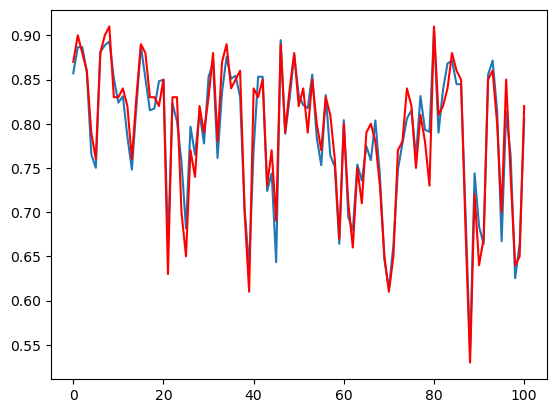

In [31]:
plt.plot(merged_df[f'{metric}'])
plt.plot(merged_df[f'{metric} (mean)'], 'r')


In [32]:
merged_df = merged_df.set_index('basin')

In [33]:
merged_df.mean(axis=0)

NSE           0.787824
NSE (mean)    0.789307
dtype: float64